# LIKWID policy-* summary

Run this notebook from a policy folder such as `performance/` or `ondemand/`.
It auto-detects subfolders like `<policy>-*` and computes:
- Total runtime [s]
- Average total power [W]
- Total energy [J]
- EDP [J*s]

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Settings
base_dir = Path('.')  # run from policy folder (e.g., performance/, ondemand/)
policy_name = base_dir.resolve().name
subfolder_pattern = f'{policy_name}-*'
benchmark_name = None  # None => process all detected benchmarks; set to a name to filter
skip_initial = 3
output_dir = base_dir  # per-benchmark CSV files are written here


In [2]:
import sys
from pathlib import Path

repo_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'tests' / 'common' / 'process_profiles_lib.py').is_file():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate tests/common/process_profiles_lib.py from current notebook path')

lib_dir = repo_root / 'tests' / 'common'
if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

from process_profiles_lib import (
    SUM_FIELDS,
    build_policy_summary,
    extract_job_id,
    find_stdout_for_job,
    list_profiles,
    load_likwid_profile,
    newest_profile_for_benchmark,
    plot_benchmark_boxplots,
    plot_likwid_timeseries,
    print_policy_context,
    run_has_fatal_error,
    summarize_profile,
)


In [3]:
per_benchmark_summary, all_output = build_policy_summary(
    base_dir=base_dir,
    subfolder_pattern=subfolder_pattern,
    benchmark_name=benchmark_name,
    skip_initial=skip_initial,
    output_dir=output_dir,
    policy_name=policy_name,
)

print_policy_context(policy_name, subfolder_pattern, benchmark_name)
all_output


Removed 15 extreme-high LIKWID samples using automatic power filtering
Removed 11 extreme-high LIKWID samples using automatic power filtering
Removed 10 extreme-high LIKWID samples using automatic power filtering
Removed 6 extreme-high LIKWID samples using automatic power filtering
Removed 17 extreme-high LIKWID samples using automatic power filtering
Removed 11 extreme-high LIKWID samples using automatic power filtering
Removed 39 extreme-high LIKWID samples using automatic power filtering
Removed 20 extreme-high LIKWID samples using automatic power filtering
Removed 331 extreme-high LIKWID samples using automatic power filtering
Removed 15 extreme-high LIKWID samples using automatic power filtering
Removed 10 extreme-high LIKWID samples using automatic power filtering
Removed 10 extreme-high LIKWID samples using automatic power filtering
Removed 4 extreme-high LIKWID samples using automatic power filtering
Removed 16 extreme-high LIKWID samples using automatic power filtering
Removed

,subfolder,benchmark,Total runtime [s],Average total power [W],Total energy [J],EDP [J*s]
0,Average,clvleaf,2474.12,433.32,1071569.92,2.651196e+09
1,everest-0,clvleaf,2473.61,432.06,1068169.63,2.642237e+09
2,everest-1,clvleaf,2470.11,435.16,1074437.05,2.653981e+09
3,everest-2,clvleaf,2473.11,428.42,1059024.05,2.619087e+09
4,everest-3,clvleaf,2478.18,428.16,1060548.25,2.628226e+09
5,everest-4,clvleaf,2475.61,442.77,1095670.61,2.712450e+09
6,Average,hpgmgfv,1341.50,508.31,681212.55,9.137574e+08
7,everest-0,hpgmgfv,1337.23,523.10,698878.30,9.345581e+08
8,everest-1,hpgmgfv,1344.73,503.38,676297.96,9.094385e+08
9,everest-2,hpgmgfv,1325.62,522.06,691485.46,9.166456e+08


Removed 15 extreme-high samples from 'Power L3 [W]' using upper bound 1.04e+03


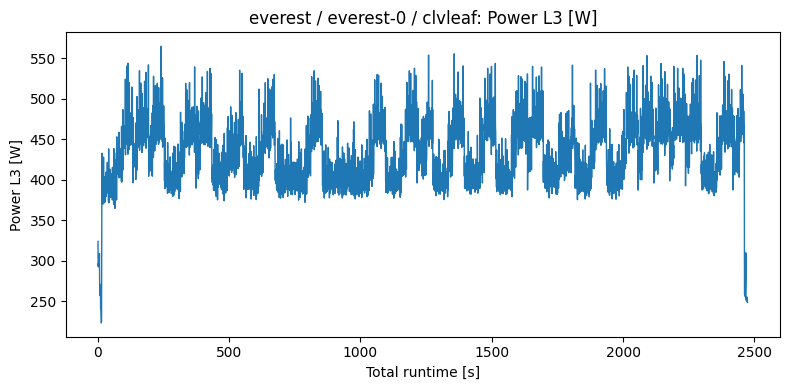

In [4]:
# Plot LIKWID sample time-series for one subfolder/benchmark and one field
selected_subfolder = 'everest-0'
selected_benchmark = None  # None => auto-pick first benchmark found in selected_subfolder
selected_field = 'Power L3 [W]'

plot_likwid_timeseries(
    base_dir=base_dir,
    selected_subfolder=selected_subfolder,
    selected_benchmark=selected_benchmark,
    selected_field=selected_field,
    skip_initial=skip_initial,
    policy_name=policy_name,
    include_benchmark_in_title=True,
)


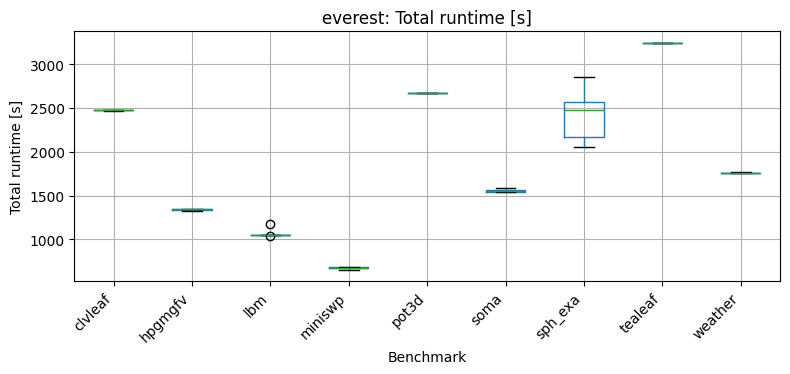

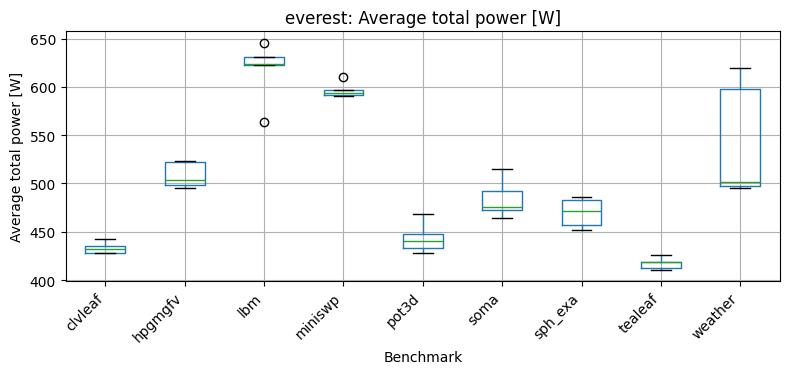

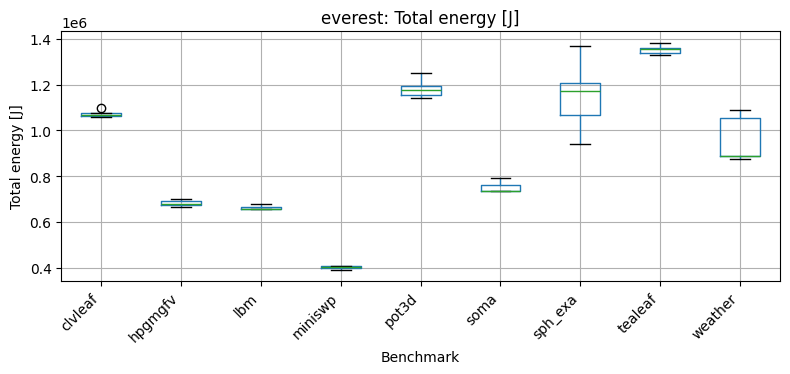

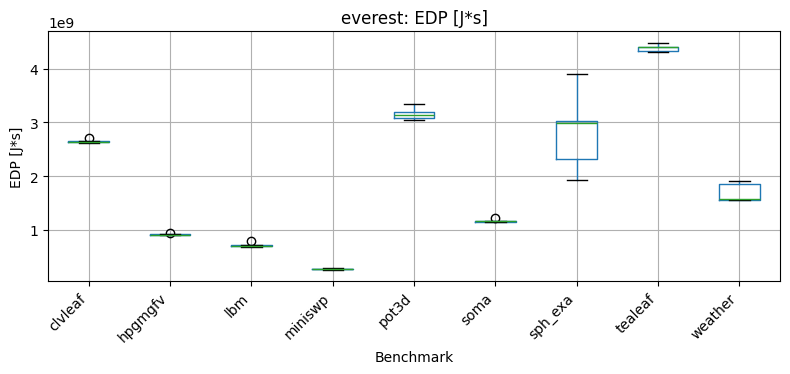

In [5]:
plot_metrics = [
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]

plot_benchmark_boxplots(
    per_benchmark_summary=per_benchmark_summary,
    policy_name=policy_name,
    plot_metrics=plot_metrics,
)
